In [1]:
%%capture
%pip install -r ../requirements.txt

In [2]:
from schema import WLD

wld = WLD(file_path="../data/example-chappy.wld")

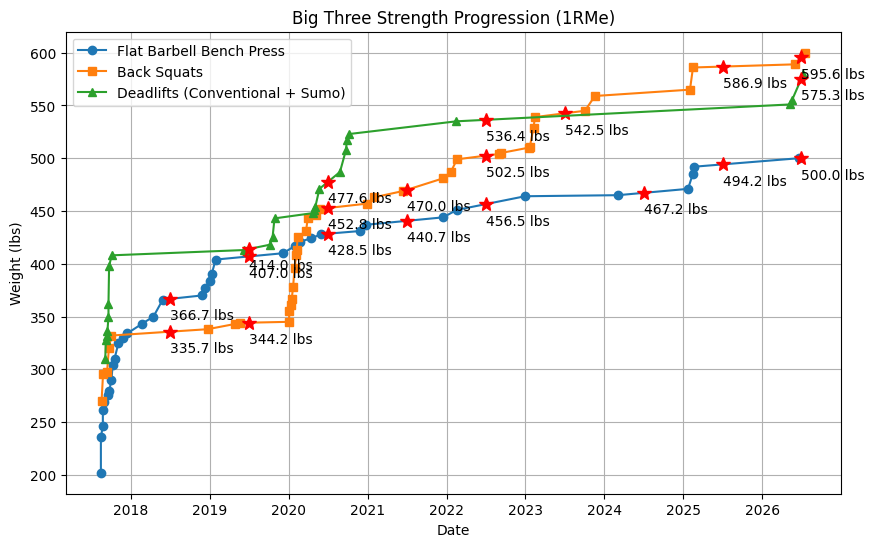

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Group both competition-legal deadlift styles into one overall progression.
exercise_variants = {
    "Flat Barbell Bench Press": {"Flat Barbell Bench Press"},
    "Back Squats": {"Back Squats"},
    "Deadlifts (Conventional + Sumo)": {
        "Conventional Deadlifts",
        "Sumo Deadlifts",
    },
}
exercises = list(exercise_variants)
exercise_data = {exercise: [] for exercise in exercises}
variant_to_exercise = {
    variant: exercise
    for exercise, variants in exercise_variants.items()
    for variant in variants
}

for workout in wld.workouts:
    for exercise in workout.exercises:
        variant = exercise.displayName()
        exercise_group = variant_to_exercise.get(variant)
        if exercise_group is not None:
            for set_data in exercise.sets:
                if set_data.weight is not None:  # Only include sets with weight data
                    exercise_data[exercise_group].append({
                        "date": workout.date,
                        "weight": set_data.oneRM,
                        "variant": variant,
                    })

# Convert to DataFrames and get max progressions
max_dfs = {}
for exercise in exercises:
    # Convert to DataFrame and sort
    df = pd.DataFrame(exercise_data[exercise])
    if not df.empty:
        df = df.sort_values("date")

        # Get max progression
        running_max = 0
        max_data = []
        for _, row in df.iterrows():
            if row["weight"] > running_max:
                running_max = row["weight"]
                max_data.append({
                    "date": row["date"],
                    "weight": row["weight"],
                    "variant": row["variant"],
                })

        max_dfs[exercise] = pd.DataFrame(max_data)

plt.figure(figsize=(10, 6))
markers = ["o", "s", "^"]
for exercise, marker in zip(exercises, markers):
    if exercise in max_dfs and not max_dfs[exercise].empty:
        df = max_dfs[exercise]

        # Plot all points
        plt.plot(df["date"], df["weight"], marker=marker, label=exercise)

        # Find and plot July 1st points
        years = df["date"].dt.year.unique()
        for year in years:
            july_date = pd.Timestamp(f"{year}-07-01")

            # Find points before and after July 1st
            before_july = df[df["date"] <= july_date]
            after_july = df[df["date"] > july_date]

            if not before_july.empty:
                last_before = before_july.iloc[-1]

                # If we have a point after July 1st, interpolate
                if not after_july.empty:
                    first_after = after_july.iloc[0]

                    # Linear interpolation
                    days_between = (first_after["date"] - last_before["date"]).days
                    days_to_july = (july_date - last_before["date"]).days
                    weight_diff = first_after["weight"] - last_before["weight"]
                    interpolated_weight = last_before["weight"] + (
                        weight_diff * days_to_july / days_between
                    )

                    plt.plot(
                        july_date,
                        interpolated_weight,
                        "r*",
                        markersize=10,
                    )
                    plt.annotate(
                        f"{interpolated_weight:.1f} lbs",
                        (july_date, interpolated_weight),
                        xytext=(0, -15),
                        textcoords="offset points",
                    )
                else:
                    # If no point after, use the last point before
                    plt.plot(
                        july_date,
                        last_before["weight"],
                        "r*",
                        markersize=10,
                    )
                    plt.annotate(
                        f'{last_before["weight"]:.1f} lbs',
                        (july_date, last_before["weight"]),
                        xytext=(0, -15),
                        textcoords="offset points",
                    )

plt.title("Big Three Strength Progression (1RMe)")
plt.xlabel("Date")
plt.ylabel("Weight (lbs)")
plt.grid(True)
plt.legend()
plt.show()

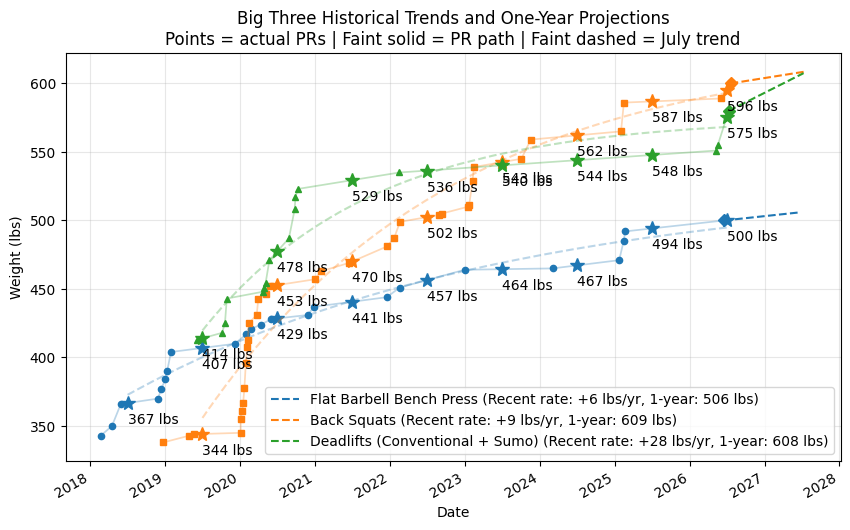


Current Progress Stats:
--------------------------------------------------
Flat Barbell Bench Press: 500 lbs
Back Squats: 600 lbs
Deadlifts (Conventional + Sumo): 580 lbs via Conventional Deadlifts


In [4]:
import numpy as np
from scipy.optimize import curve_fit

DAYS_PER_YEAR = 365.2425


def asymptotic_func(x, asymptote, growth, rate):
    return asymptote - growth * np.exp(-rate * x)

plt.figure(figsize=(10, 6))
markers = ["o", "s", "^"]

for exercise, marker in zip(exercises, markers):
    if exercise in max_dfs and not max_dfs[exercise].empty:
        df = max_dfs[exercise]

        # Filter data from 2018 onwards
        df = df[df["date"].dt.year >= 2018]

        # Find July 1st points for ALL years between min and max date
        selected_points = []
        min_year = df["date"].dt.year.min()
        max_year = df["date"].dt.year.max()

        for year in range(min_year, max_year + 1):
            july_date = pd.Timestamp(f"{year}-07-01")

            # Find points before and after July 1st
            before_july = df[df["date"] <= july_date]
            after_july = df[df["date"] > july_date]

            if not before_july.empty:
                last_before = before_july.iloc[-1]

                # If we have a point after July 1st, interpolate
                if not after_july.empty:
                    first_after = after_july.iloc[0]

                    # Linear interpolation
                    days_between = (first_after["date"] - last_before["date"]).days
                    days_to_july = (july_date - last_before["date"]).days
                    weight_diff = first_after["weight"] - last_before["weight"]
                    interpolated_weight = last_before["weight"] + (
                        weight_diff * days_to_july / days_between
                    )

                    selected_points.append((july_date, interpolated_weight))
                else:
                    # If no point after, use the last point before
                    selected_points.append((july_date, last_before["weight"]))

        if len(selected_points) >= 2:
            selected_dates = [p[0] for p in selected_points]
            selected_weights = [p[1] for p in selected_points]

            # Use the latest July-to-July change as the recent annual rate.
            years_between = (
                selected_dates[-1] - selected_dates[-2]
            ).days / DAYS_PER_YEAR
            recent_rate = (
                selected_weights[-1] - selected_weights[-2]
            ) / years_between

            # Anchor the one-year projection at the latest actual record,
            # including PRs set after the most recent July 1 snapshot.
            current_date = df["date"].iloc[-1]
            current_weight = df["weight"].iloc[-1]
            projection_end = current_date + pd.DateOffset(years=1)
            future_dates = pd.date_range(current_date, projection_end, periods=100)
            elapsed_years = (future_dates - current_date).days / DAYS_PER_YEAR
            projected_weights = current_weight + recent_rate * elapsed_years

            # Keep the actual-record path faint, then draw its points
            # separately at full opacity so the observations stand out.
            line = plt.plot(
                df["date"],
                df["weight"],
                linestyle="-",
                linewidth=1.25,
                alpha=0.3,
            )[0]
            line_color = line.get_color()
            plt.plot(
                df["date"],
                df["weight"],
                linestyle="none",
                marker=marker,
                markersize=4.5,
                color=line_color,
            )

            # Fit an asymptotic historical trend to the annual snapshots.
            # It describes history only; current rates and projections below
            # come from recent observed progress instead of this fit.
            historical_dates = pd.date_range(
                selected_dates[0], selected_dates[-1], periods=300
            )
            historical_x = np.array(
                [(date - selected_dates[0]).days for date in selected_dates]
            )
            smooth_x = (historical_dates - selected_dates[0]).days
            try:
                historical_fit, _ = curve_fit(
                    asymptotic_func,
                    historical_x,
                    selected_weights,
                    p0=[
                        max(selected_weights) * 1.1,
                        max(selected_weights) * 0.5,
                        0.001,
                    ],
                    bounds=(
                        [max(selected_weights), 0, 0],
                        [
                            max(selected_weights) * 1.5,
                            max(selected_weights),
                            0.01,
                        ],
                    ),
                )
                historical_weights = asymptotic_func(
                    smooth_x, *historical_fit
                )
                plt.plot(
                    historical_dates,
                    historical_weights,
                    color=line_color,
                    linestyle="--",
                    linewidth=1.5,
                    alpha=0.3,
                )
            except (RuntimeError, ValueError):
                print(f"Could not fit historical curve for {exercise}")

            # Plot July 1 snapshots as stars.
            for date, weight in selected_points:
                plt.plot(date, weight, marker="*", markersize=10, color=line_color)
                plt.annotate(
                    f"{weight:.0f} lbs",
                    (date, weight),
                    xytext=(0, -15),
                    textcoords="offset points",
                )

            # Highlight the latest actual record where the projection begins.
            plt.plot(
                current_date,
                current_weight,
                marker="D",
                markersize=6,
                color=line_color,
            )

            # Project one year from the latest actual record at the recent rate.
            projected_weight = projected_weights[-1]
            plt.plot(
                future_dates,
                projected_weights,
                "--",
                color=line_color,
                label=(
                    f"{exercise} (Recent rate: {recent_rate:+.0f} lbs/yr, "
                    f"1-year: {projected_weight:.0f} lbs)"
                ),
            )

plt.title(
    "Big Three Historical Trends and One-Year Projections\n"
    "Points = actual PRs | Faint solid = PR path | Faint dashed = July trend"
)
plt.xlabel("Date")
plt.ylabel("Weight (lbs)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

# Print current stats
print("\nCurrent Progress Stats:")
print("-" * 50)
for exercise in exercises:
    if exercise in max_dfs and not max_dfs[exercise].empty:
        df = max_dfs[exercise]
        current_weight = df["weight"].iloc[-1]
        variant_suffix = (
            f" via {df['variant'].iloc[-1]}"
            if len(exercise_variants[exercise]) > 1
            else ""
        )
        print(f"{exercise}: {current_weight:.0f} lbs{variant_suffix}")